# Load model

In [1]:
%%capture
!pip install pip3-autoremove
!pip-autoremove torch torchvision torchaudio -y
!pip install torch torchvision torchaudio xformers --index-url https://download.pytorch.org/whl/cu121
!pip install unsloth
# Also get the latest nightly Unsloth!
!pip uninstall unsloth -y && pip install --upgrade --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git
!pip install --upgrade --no-cache-dir transformers

In [2]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 1024 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Meta-Llama-3.1-8B-bnb-4bit",      # Llama-3.1 2x faster
    "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    "unsloth/Meta-Llama-3.1-70B-bnb-4bit",
    "unsloth/Meta-Llama-3.1-405B-bnb-4bit",    # 4bit for 405b!
    "unsloth/Mistral-Small-Instruct-2409",     # Mistral 22b 2x faster!
    "unsloth/mistral-7b-instruct-v0.3-bnb-4bit",
    "unsloth/Phi-3.5-mini-instruct",           # Phi-3.5 2x faster!
    "unsloth/Phi-3-medium-4k-instruct",
    "unsloth/gemma-2-9b-bnb-4bit",
    "unsloth/gemma-2-27b-bnb-4bit",            # Gemma 2x faster!

    "unsloth/Llama-3.2-1B-bnb-4bit",           # NEW! Llama 3.2 models
    "unsloth/Llama-3.2-1B-Instruct-bnb-4bit",
    "unsloth/Llama-3.2-3B-bnb-4bit",
    "unsloth/Llama-3.2-3B-Instruct-bnb-4bit",

    "unsloth/Llama-3.3-70B-Instruct-bnb-4bit" # NEW! Llama 3.3 70B!
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct", # or choose "unsloth/Llama-3.2-1B-Instruct"
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2025-08-07 18:06:46.990294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754590007.344479      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754590007.447524      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.8.2: Fast Llama patching. Transformers: 4.55.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.5.1+cu121. CUDA: 7.5. CUDA Toolkit: 12.1. Triton: 3.1.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [3]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2025.8.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


# Load dataset

In [5]:
import json

with open('/kaggle/working/train_reasoned_data.json', 'r') as f:
  train_data = json.loads(f.read())
  f.close()

with open('/kaggle/working/val_reasoned_data.json', 'r') as f:
  val_data = json.loads(f.read())
  f.close()

for d in train_data:
  d['label'] = d['label'].capitalize()
  d['types'] = [x.split(' ')[0].capitalize() for x in d['types']]

for d in val_data:
  d['label'] = d['label'].capitalize()
  d['types'] = [x.split(' ')[0].capitalize() for x in d['types']]

In [6]:
def form_message(data_obj):
  chat = {'conversations': []}
  chat['conversations'].append({
        "role": "system",
        "content": (
            "You are an expert in analyzing social media content for diabetes-related stigma.\n\n"
            "Your task is to classify the presence and type of stigma in a given social media post.\n\n"
            "Classification steps:\n"
            "1. Determine if the post expresses stigma:\n"
            "   - Yes stigma: Contains stigmatizing content or implications.\n"
            "   - No stigma: Neutral, supportive, or stigma-free.\n\n"
            "2. If 'Yes stigma', identify all applicable types:\n"
            "   - Experienced: Direct discrimination or exclusion due to diabetes.\n"
            "   - Perceived: Awareness or assumption that others hold negative views.\n"
            "   - Anticipated: Fear or expectation of being stigmatized.\n"
            "   - Internalized: Shame or self-blame from negative diabetes stereotypes.\n"
            "   - Intersectional: Stigma compounded by other factors (e.g., obesity, race).\n\n"
            "   If 'No stigma', return an empty list for Type.\n\n"
            "3. Provide a brief explanation (max 50 words) for your decision.\n\n"
            "Respond in this exact format:\n"
            "Label: [Yes stigma / No stigma]\n"
            "Type: [List of applicable types or []]\n"
            "Reasoning: [Your explanation]"
        )
    })

  chat['conversations'].append({
        "role": "user",
        "content": (
            f"Title: {d['title']}\n"
            f"Text: {d['post text']}\n\n"
            "Analyze the post for diabetes-related stigma."
        )
    })

  chat['conversations'].append({'role': 'assistant',
               'content': (f"Label: {d['label']}\n"
                           f"Type: {d['types']}\n"
                           f"Reasoning: {d['reasoning']}"
                           )
               })
  return chat

In [7]:
train_dataset = []
for d in train_data:
  train_dataset.append(form_message(d))

val_dataset = []
for d in val_data:
  val_dataset.append(form_message(d))

In [8]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_dataset)
val_dataset = Dataset.from_list(val_dataset)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['conversations'],
    num_rows: 1054
})
Dataset({
    features: ['conversations'],
    num_rows: 151
})


In [9]:
train_dataset[0]['conversations']

[{'content': "You are an expert in analyzing social media content for diabetes-related stigma.\n\nYour task is to classify the presence and type of stigma in a given social media post.\n\nClassification steps:\n1. Determine if the post expresses stigma:\n   - Yes stigma: Contains stigmatizing content or implications.\n   - No stigma: Neutral, supportive, or stigma-free.\n\n2. If 'Yes stigma', identify all applicable types:\n   - Experienced: Direct discrimination or exclusion due to diabetes.\n   - Perceived: Awareness or assumption that others hold negative views.\n   - Anticipated: Fear or expectation of being stigmatized.\n   - Internalized: Shame or self-blame from negative diabetes stereotypes.\n   - Intersectional: Stigma compounded by other factors (e.g., obesity, race).\n\n   If 'No stigma', return an empty list for Type.\n\n3. Provide a brief explanation (max 50 words) for your decision.\n\nRespond in this exact format:\nLabel: [Yes stigma / No stigma]\nType: [List of applicab

In [10]:
from unsloth.chat_templates import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)

def formatting_prompts_func(examples):
    convos = examples["conversations"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts, }

In [11]:
from unsloth.chat_templates import standardize_sharegpt
# ds1 = standardize_sharegpt(dataset)
train_dataset = train_dataset.map(formatting_prompts_func, batched = True,)
val_dataset = val_dataset.map(formatting_prompts_func, batched = True,)

Map:   0%|          | 0/1054 [00:00<?, ? examples/s]

Map:   0%|          | 0/151 [00:00<?, ? examples/s]

# Train the model

In [12]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    data_collator = DataCollatorForSeq2Seq(tokenizer = tokenizer),
    dataset_num_proc = 2,
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 20, # Set this for 1 full training run.
        eval_steps = 20,
        eval_strategy='steps',
        save_steps = 40,
        save_strategy='steps',
        save_total_limit = 5,
        # max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(), # not is_bfloat16_supported()
        bf16 = is_bfloat16_supported(),
        logging_strategy = 'steps',
        logging_steps = 40,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use this for WandB etc
    ),
)

Unsloth: Tokenizing ["text"]:   0%|          | 0/1054 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/151 [00:00<?, ? examples/s]

In [13]:
from unsloth.chat_templates import train_on_responses_only
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|start_header_id|>user<|end_header_id|>\n\n",
    response_part = "<|start_header_id|>assistant<|end_header_id|>\n\n",
)

Map (num_proc=4):   0%|          | 0/1054 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/151 [00:00<?, ? examples/s]

In [14]:
#@title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
3.07 GB of memory reserved.


In [15]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,054 | Num Epochs = 20 | Total steps = 1,320
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
20,No log,0.497322
40,0.591600,0.446949
60,0.591600,0.431363
80,0.447700,0.423996
100,0.447700,0.427061
120,0.369600,0.420028
140,0.369600,0.434731
160,0.280300,0.446021
180,0.280300,0.452447
200,0.252500,0.464143


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


In [16]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory         /max_memory*100, 3)
lora_percentage = round(used_memory_for_lora/max_memory*100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

18667.8403 seconds used for training.
311.13 minutes used for training.
Peak reserved memory = 5.227 GB.
Peak reserved memory for training = 2.157 GB.
Peak reserved memory % of max memory = 35.459 %.
Peak reserved memory for training % of max memory = 14.633 %.


In [ ]:
model.push_to_hub("haji80mr-uoft/Llama-tuned-Lora-only-V2", token = "") # Online saving
tokenizer.push_to_hub("haji80mr-uoft/Llama-tuned-Lora-only-V2", token = "") # Online saving

README.md:   0%|          | 0.00/618 [00:00<?, ?B/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...p8qjpt3o2/adapter_model.safetensors:   0%|          | 45.8kB / 97.3MB            

Saved model to https://huggingface.co/haji80mr-uoft/Llama-tuned-Lora-only-V2


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  /tmp/tmpuyd5i73c/tokenizer.json       : 100%|##########| 17.2MB / 17.2MB            

In [ ]:
model.push_to_hub_merged("haji80mr-uoft/Llama-tuned-Lora-merged-V2", tokenizer, save_method = "merged_16bit", token = "")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...tuned-Lora-merged-V2/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...V2/model-00002-of-00002.safetensors:   0%|          | 2.10MB / 1.46GB            

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [02:10<00:00, 65.06s/it]


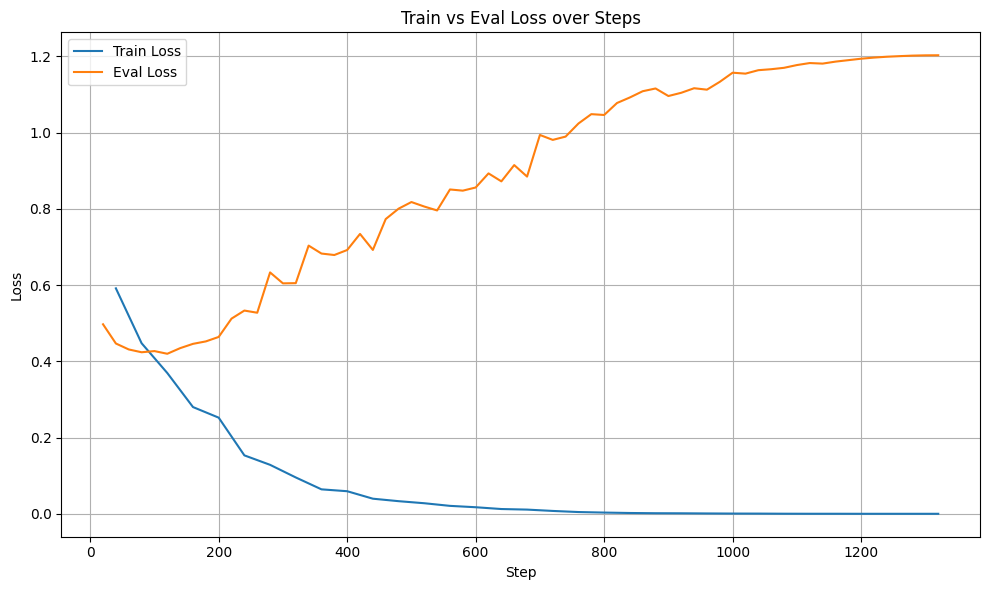

In [19]:
import matplotlib.pyplot as plt

# Step 1: Extract logs from trainer
log_history = trainer.state.log_history

# Step 2: Filter train loss and eval loss logs
train_logs = [log for log in log_history if "loss" in log and "step" in log]
eval_logs  = [log for log in log_history if "eval_loss" in log and "step" in log]

# Step 3: Extract steps and loss values
train_steps = [log["step"] for log in train_logs]
train_losses = [log["loss"] for log in train_logs]

eval_steps = [log["step"] for log in eval_logs]
eval_losses = [log["eval_loss"] for log in eval_logs]

# Step 4: Plotting both on the same chart
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, label="Train Loss")
plt.plot(eval_steps, eval_losses, label="Eval Loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train vs Eval Loss over Steps")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
